# Genetic Algorithm-Enhanced Diabetes E-Diagnosis

**Pipeline:** Pima Indians Diabetes Dataset → Pre-processing *(Chang et al., 2022)* → GA Feature Selection *(Kangra & Singh, 2024)* → Classification (J48 DT, RF, NB) → MLflow Tracking → Results

## 1. INSTALL LIBRARIES

In [ ]:
!pip install pygad mlflow kagglehub --quiet

## 2. IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import warnings
import os
import math
import mlflow
import mlflow.sklearn
import pygad
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import kagglehub

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 3. LOAD DATASET

In [ ]:
# Download Pima Indians Diabetes dataset from Kaggle
path = kagglehub.dataset_download('uciml/pima-indians-diabetes-database')
print('Dataset Path:', path)
print(os.listdir(path))

csv_path = os.path.join(path, 'diabetes.csv')
df = pd.read_csv(csv_path)

print('\nDataset Loaded Successfully')
print('Dataset Shape:', df.shape)
df.head()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset Path: /kaggle/input/pima-indians-diabetes-database
['diabetes.csv']

Dataset Loaded Successfully
Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. PRE-PROCESSING  *(Chang et al., 2022)*

**4.1 HANDLE INVALID ZEROS**

Biologically invalid zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` are replaced with column median.

In [ ]:
ZERO_INVALID_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero Counts Before Imputation:')
print(df[ZERO_INVALID_COLS].eq(0).sum())

for col in ZERO_INVALID_COLS:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

print('\nZero Counts After Imputation:')
print(df[ZERO_INVALID_COLS].eq(0).sum())

Zero Counts Before Imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Zero Counts After Imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


**4.2 STANDARDIZATION**

`StandardScaler` applied to `DiabetesPedigreeFunction`, `Age`, and `Insulin` to normalise high-variance features.

In [ ]:
SCALE_COLS = ['DiabetesPedigreeFunction', 'Age', 'Insulin']

scaler = StandardScaler()
df[SCALE_COLS] = scaler.fit_transform(df[SCALE_COLS])

print('Standardization Complete')
print(df[SCALE_COLS].describe().loc[['mean', 'std']].round(4))

Standardization Complete
      DiabetesPedigreeFunction     Age  Insulin
mean                    0.0000  0.0000   0.0000
std                     1.0007  1.0007   1.0007


## 5. TRAIN / TEST SPLIT

70 % Training (538 samples) / 30 % Testing (230 samples) — matches (Chang et al., 2022) exactly.

In [ ]:
FEATURE_NAMES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

X = df[FEATURE_NAMES].values
y = df['Outcome'].values

TRAIN_SIZE = 538
X_train, X_test = X[:TRAIN_SIZE], X[TRAIN_SIZE:]
y_train, y_test = y[:TRAIN_SIZE], y[TRAIN_SIZE:]

print('Training Samples:', X_train.shape[0])
print('Testing  Samples:', X_test.shape[0])

Training Samples: 538
Testing  Samples: 230


**PCA Visualization** *(exploratory)*

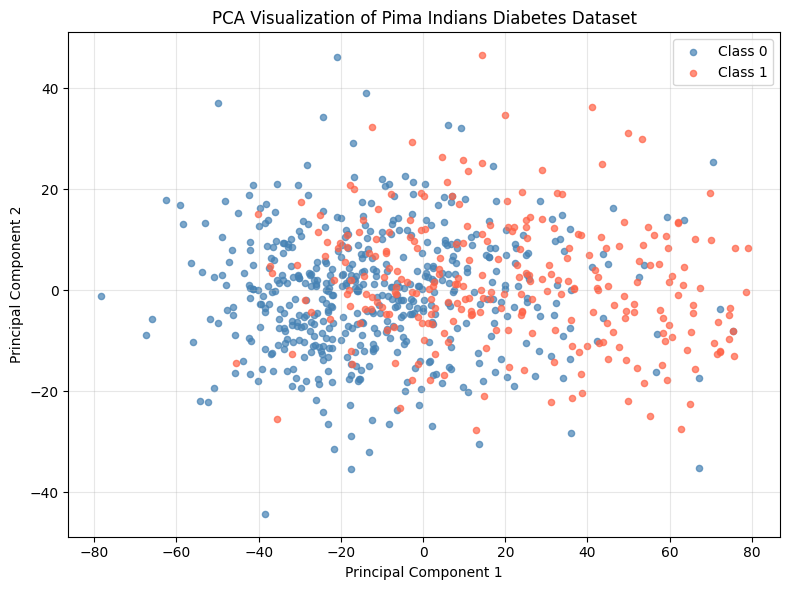

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Outcome': y})

plt.figure(figsize=(8, 6))
for label, colour in zip([0, 1], ['steelblue', 'tomato']):
    subset = pca_df[pca_df['Outcome'] == label]
    plt.scatter(subset['PCA1'], subset['PCA2'],
                label=f'Class {label}', alpha=0.7, color=colour, s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Pima Indians Diabetes Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. GENETIC ALGORITHM FEATURE SELECTION  *(Kangra & Singh, 2024)*

| Parameter | Value |
|---|---|
| Encoding | Binary (8-bit chromosome) |
| Fitness | Maximise RF accuracy on test set |
| Population | 100 |
| Generations | 50 |
| Crossover probability | 0.6 |
| Mutation probability | 0.3 (uniform random) |
| Selection | Tournament (K=3) |

In [ ]:
GA_POP_SIZE    = 100
GA_GENERATIONS = 50
GA_CROSSOVER_P = 0.6
GA_MUTATION_P  = 0.3
NUM_FEATURES   = X_train.shape[1]   # 8

# RF used only inside GA fitness (internal, not final model)
_ga_rf = RandomForestClassifier(n_estimators=100, random_state=42)


def fitness_function(ga_instance, solution, solution_idx):
    """Binary chromosome: gene > 0.5 means feature selected. Fitness = RF test accuracy."""
    selected = np.where(np.array(solution) > 0.5)[0]
    if len(selected) == 0:
        return 0.0
    _ga_rf.fit(X_train[:, selected], y_train)
    preds = _ga_rf.predict(X_test[:, selected])
    return accuracy_score(y_test, preds)


print('Starting Genetic Algorithm...')
print('Population Size :', GA_POP_SIZE)
print('Generations     :', GA_GENERATIONS)

ga_instance = pygad.GA(
    num_generations       = GA_GENERATIONS,
    num_parents_mating    = int(GA_POP_SIZE * GA_CROSSOVER_P),
    fitness_func          = fitness_function,
    sol_per_pop           = GA_POP_SIZE,
    num_genes             = NUM_FEATURES,
    gene_type             = float,
    init_range_low        = 0,
    init_range_high       = 1,
    gene_space            = [0, 1],
    parent_selection_type = 'tournament',
    K_tournament          = 3,
    crossover_type        = 'single_point',
    crossover_probability = GA_CROSSOVER_P,
    mutation_type         = 'random',
    mutation_probability  = GA_MUTATION_P,
    keep_elitism          = 1,
    random_seed           = 42,
    suppress_warnings     = True
)

ga_instance.run()
print('GA completed.')

Starting Genetic Algorithm...
Population Size : 100
Generations     : 50


## 7. BEST FEATURE SUBSET

In [17]:
best_solution, best_fitness, _ = ga_instance.best_solution()

selected_indices  = np.where(np.array(best_solution) > 0.5)[0]
selected_features = [FEATURE_NAMES[i] for i in selected_indices]

print('GA Completed Successfully')
print('Best Accuracy (RF, test set):', round(best_fitness, 4))
print('Selected Features:', selected_features)
print(f'Number selected: {len(selected_features)} / {NUM_FEATURES}')

GA Completed Successfully
Best Accuracy (RF, test set): 0.8087
Selected Features: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Number selected: 7 / 8


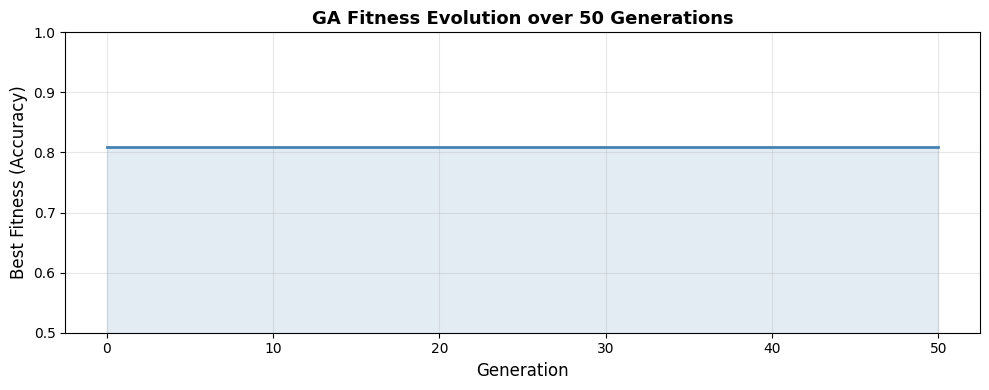

In [18]:
# ── Chart 1: GA Fitness Evolution ─────────────────────────────────────────────
fitness_history = ga_instance.best_solutions_fitness

plt.figure(figsize=(10, 4))
plt.plot(fitness_history, color='steelblue', linewidth=2)
plt.fill_between(range(len(fitness_history)), fitness_history, alpha=0.15, color='steelblue')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Best Fitness (Accuracy)', fontsize=12)
plt.title('GA Fitness Evolution over 50 Generations', fontsize=13, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

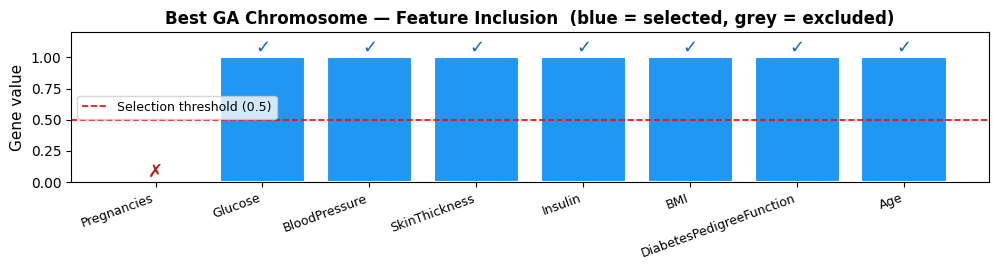

In [19]:
# ── Chart 2: Best Chromosome Feature Selection ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 2.8))
colors = ['#2196F3' if v > 0.5 else '#CFD8DC' for v in best_solution]
bars = ax.bar(FEATURE_NAMES, best_solution, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Selection threshold (0.5)')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Gene value', fontsize=11)
ax.set_title('Best GA Chromosome — Feature Inclusion  (blue = selected, grey = excluded)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
for bar in bars:
    lbl = '✓' if bar.get_height() > 0.5 else '✗'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            lbl, ha='center', fontsize=13, fontweight='bold',
            color='#1565C0' if bar.get_height() > 0.5 else '#B71C1C')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. STATISTICAL ANALYSIS OF SELECTED FEATURES

In [20]:
selected_df = df[selected_features + ['Outcome']]
print('Selected Features:', selected_features)

Selected Features: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [21]:
print('DESCRIPTIVE STATISTICS OF SELECTED FEATURES')
stats_df = selected_df.describe().T
stats_df['median']   = selected_df.median()
stats_df['variance'] = selected_df.var()
print(stats_df)

DESCRIPTIVE STATISTICS OF SELECTED FEATURES
                          count          mean        std        min  \
Glucose                   768.0  1.216562e+02  30.438286  44.000000   
BloodPressure             768.0  7.238672e+01  12.096642  24.000000   
SkinThickness             768.0  2.910807e+01   8.791221   7.000000   
Insulin                   768.0  1.503427e-17   1.000652  -1.467353   
BMI                       768.0  3.245521e+01   6.875177  18.200000   
DiabetesPedigreeFunction  768.0  2.451743e-16   1.000652  -1.189553   
Age                       768.0  1.931325e-16   1.000652  -1.041549   
Outcome                   768.0  3.489583e-01   0.476951   0.000000   

                                25%         50%         75%         max  \
Glucose                   99.750000  117.000000  140.250000  199.000000   
BloodPressure             64.000000   72.000000   80.000000  122.000000   
SkinThickness             25.000000   29.000000   32.000000   99.000000   
Insulin         

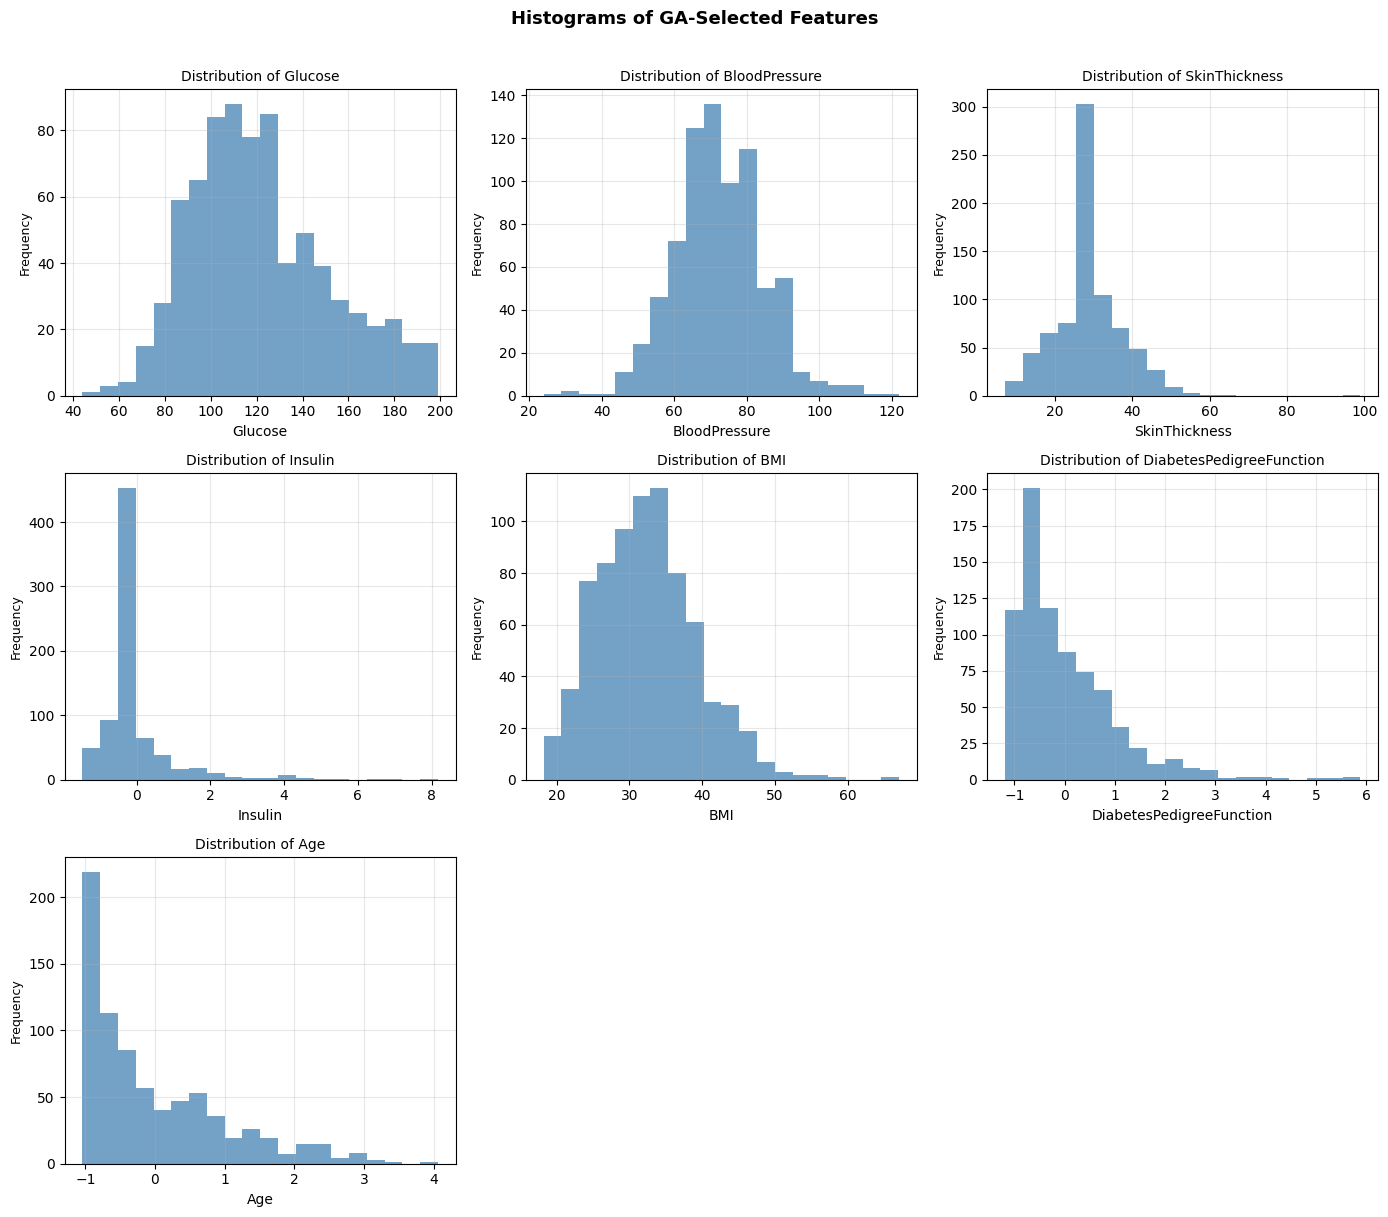

In [22]:
# HISTOGRAMS OF SELECTED FEATURES
n = len(selected_features)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    axes[i].hist(selected_df[feature], bins=20, alpha=0.75, color='steelblue')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].set_title(f'Distribution of {feature}', fontsize=10)
    axes[i].grid(alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of GA-Selected Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

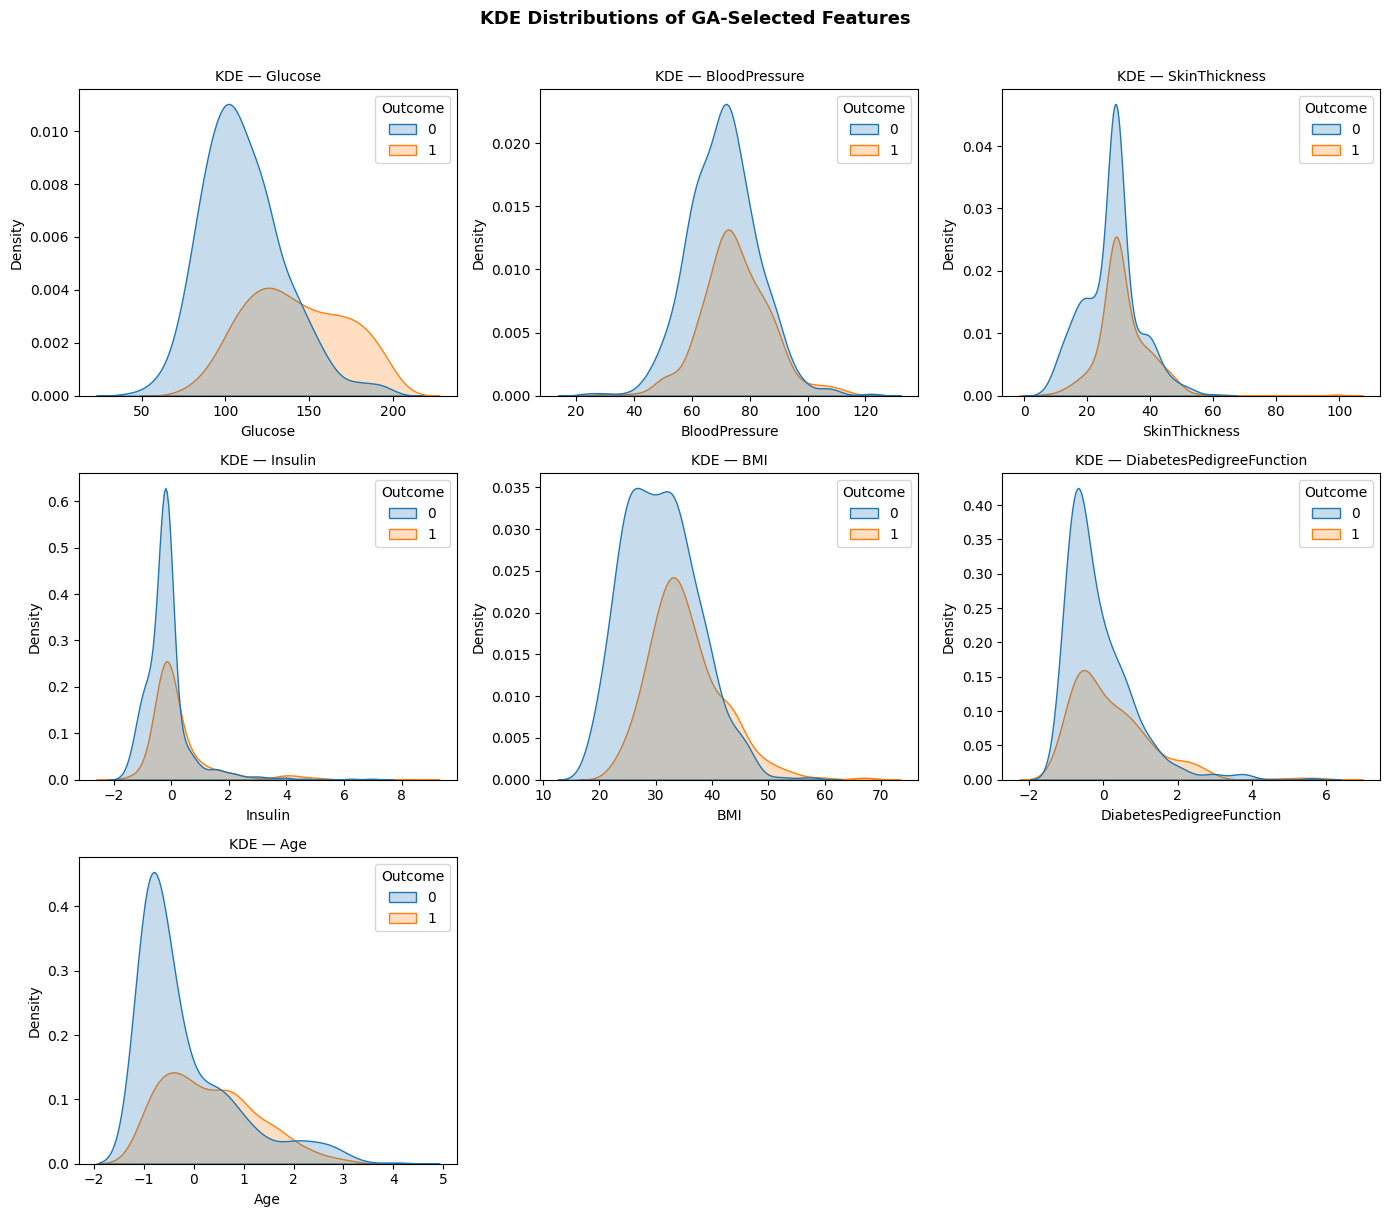

In [24]:
# KDE DISTRIBUTION PLOTS
n = len(selected_features)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.kdeplot(data=selected_df, x=feature, hue='Outcome', fill=True, ax=axes[i])
    axes[i].set_title(f'KDE — {feature}', fontsize=10)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('KDE Distributions of GA-Selected Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

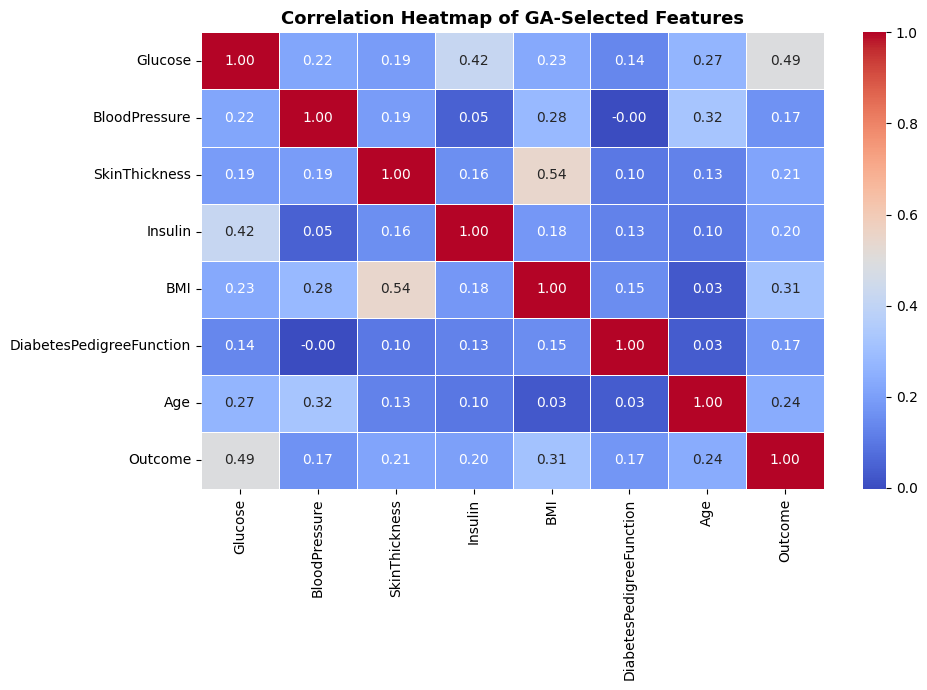

In [25]:
# CORRELATION HEATMAP
plt.figure(figsize=(10, 7))
sns.heatmap(selected_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of GA-Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. CLASSIFICATION & MLFLOW TRACKING  *(Source (Chang et al., 2022) classifiers)*

Three classifiers from Source (Chang et al., 2022)   are trained on **two** feature sets:

| Classifier | sklearn equivalent |
|---|---|
| J48 Decision Tree | `DecisionTreeClassifier(criterion='entropy')` |
| Random Forest | `RandomForestClassifier(n_estimators=100)` |
| Naïve Bayes | `GaussianNB()` |

In [26]:
# GA-selected feature subsets
X_train_ga  = X_train[:, selected_indices]
X_test_ga   = X_test[:, selected_indices]

# All-features baseline
X_train_all = X_train
X_test_all  = X_test

print(f'GA subset    — train: {X_train_ga.shape},  test: {X_test_ga.shape}')
print(f'All features — train: {X_train_all.shape}, test: {X_test_all.shape}')

GA subset    — train: (538, 7),  test: (230, 7)
All features — train: (538, 8), test: (230, 8)


In [27]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """Fit model, return metrics dict + confusion matrix."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = (
        model.predict_proba(X_te)[:, 1]
        if hasattr(model, 'predict_proba') else preds
    )
    return {
        'model'      : model,
        'preds'      : preds,
        'metrics': {
            'Accuracy'   : round(accuracy_score(y_te, preds),                   4),
            'Precision'  : round(precision_score(y_te, preds, zero_division=0), 4),
            'Sensitivity': round(recall_score(y_te, preds, zero_division=0),    4),
            'F-score'    : round(f1_score(y_te, preds, zero_division=0),        4),
            'AUC'        : round(roc_auc_score(y_te, proba),                    4),
        }
    }


MODELS = {
    'J48 DT': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'RF'    : RandomForestClassifier(n_estimators=100, random_state=42),
    'NB'    : GaussianNB(),
}
MODEL_FULL_NAMES = {
    'J48 DT': 'J48 Decision Tree',
    'RF'    : 'Random Forest',
    'NB'    : 'Naïve Bayes',
}

print('Classifiers ready:', list(MODELS.keys()))

Classifiers ready: ['J48 DT', 'RF', 'NB']


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# MLFLOW — logs all runs; charts are shown below with matplotlib
# ══════════════════════════════════════════════════════════════════════════════
mlflow.set_experiment('GA_Diabetes_EDiagnosis')

results_ga  = {}
results_all = {}

for key, model in MODELS.items():

    # ── GA-selected features ──────────────────────────────────────────────────
    with mlflow.start_run(run_name=f'{MODEL_FULL_NAMES[key]} — GA'):
        mlflow.log_param('ga_population_size', GA_POP_SIZE)
        mlflow.log_param('ga_generations',     GA_GENERATIONS)
        mlflow.log_param('ga_crossover_prob',  GA_CROSSOVER_P)
        mlflow.log_param('ga_mutation_prob',   GA_MUTATION_P)
        mlflow.log_param('ga_selection_type',  'tournament')
        mlflow.log_param('selected_features',  str(selected_features))
        mlflow.log_param('num_features',       len(selected_features))
        mlflow.log_param('classifier',         MODEL_FULL_NAMES[key])
        mlflow.log_param('feature_set',        'GA-selected')

        res_ga = evaluate_model(
            clone(model), X_train_ga, y_train, X_test_ga, y_test
        )
        mlflow.log_metrics(res_ga['metrics'])
        results_ga[key] = res_ga

    # ── All-features baseline ─────────────────────────────────────────────────
    with mlflow.start_run(run_name=f'{MODEL_FULL_NAMES[key]} — All features'):
        mlflow.log_param('classifier',   MODEL_FULL_NAMES[key])
        mlflow.log_param('feature_set',  'All features')
        mlflow.log_param('num_features', NUM_FEATURES)

        res_all = evaluate_model(
            clone(model), X_train_all, y_train, X_test_all, y_test
        )
        mlflow.log_metrics(res_all['metrics'])
        results_all[key] = res_all

print('All 6 runs logged to MLflow experiment: GA_Diabetes_EDiagnosis')

2026/05/16 19:49:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/16 19:49:46 INFO mlflow.store.db.utils: Updating database tables
2026/05/16 19:49:49 INFO mlflow.tracking.fluent: Experiment with name 'GA_Diabetes_EDiagnosis' does not exist. Creating a new experiment.


All 6 runs logged to MLflow experiment: GA_Diabetes_EDiagnosis


## 10. RESULTS — CHARTS & TABLES

> All charts below are generated with matplotlib and will **always display in Colab** regardless of MLflow UI status.

In [29]:
# ── Build summary DataFrames ──────────────────────────────────────────────────
METRICS = ['Accuracy', 'Precision', 'Sensitivity', 'F-score', 'AUC']

df_ga  = pd.DataFrame(
    {MODEL_FULL_NAMES[k]: v['metrics'] for k, v in results_ga.items()},
    index=METRICS
).T

df_all = pd.DataFrame(
    {MODEL_FULL_NAMES[k]: v['metrics'] for k, v in results_all.items()},
    index=METRICS
).T

print('──── GA-Selected Features', '─' * 42)
print(f'Features used ({len(selected_features)}): {selected_features}\n')
print(df_ga.to_string())
print()
print('──── All Features (Baseline)', '─' * 40)
print(df_all.to_string())

──── GA-Selected Features ──────────────────────────────────────────
Features used (7): ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

                   Accuracy  Precision  Sensitivity  F-score     AUC
J48 Decision Tree    0.7043     0.5696       0.5696   0.5696  0.6722
Random Forest        0.8087     0.7536       0.6582   0.7027  0.8386
Naïve Bayes          0.7609     0.6765       0.5823   0.6259  0.8385

──── All Features (Baseline) ────────────────────────────────────────
                   Accuracy  Precision  Sensitivity  F-score     AUC
J48 Decision Tree    0.7130     0.5802       0.5949   0.5875  0.6849
Random Forest        0.7957     0.7424       0.6203   0.6759  0.8595
Naïve Bayes          0.7870     0.7143       0.6329   0.6711  0.8460


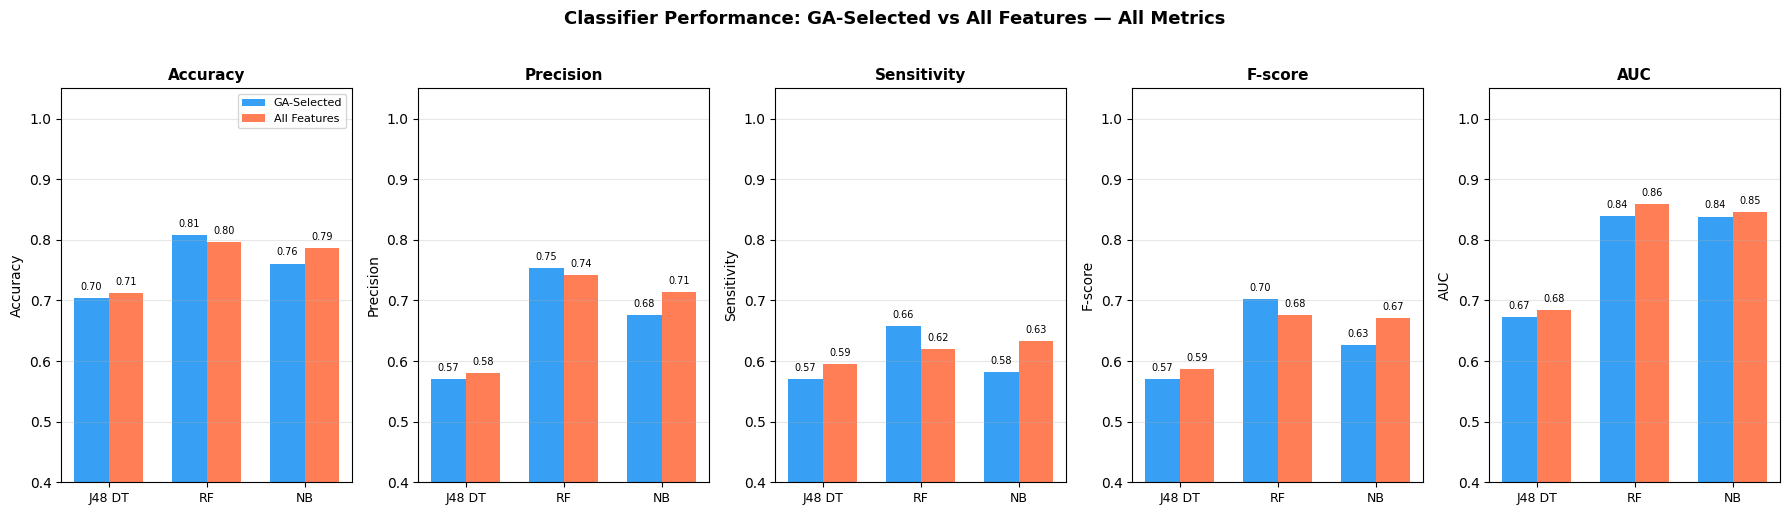

In [30]:
# ── Chart 3: Grouped Bar — all metrics, GA vs All features ───────────────────
clf_labels  = [MODEL_FULL_NAMES[k] for k in MODELS]
x           = np.arange(len(clf_labels))
width       = 0.35

fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5), sharey=False)

for ax, metric in zip(axes, METRICS):
    vals_ga  = [results_ga[k]['metrics'][metric]  for k in MODELS]
    vals_all = [results_all[k]['metrics'][metric] for k in MODELS]

    b1 = ax.bar(x - width/2, vals_ga,  width, label='GA-Selected', color='#2196F3', alpha=0.9)
    b2 = ax.bar(x + width/2, vals_all, width, label='All Features', color='#FF7043', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(['J48 DT', 'RF', 'NB'], fontsize=9)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0.4, 1.05)
    ax.grid(axis='y', alpha=0.3)
    if metric == 'Accuracy':
        ax.legend(fontsize=8)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('Classifier Performance: GA-Selected vs All Features — All Metrics',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

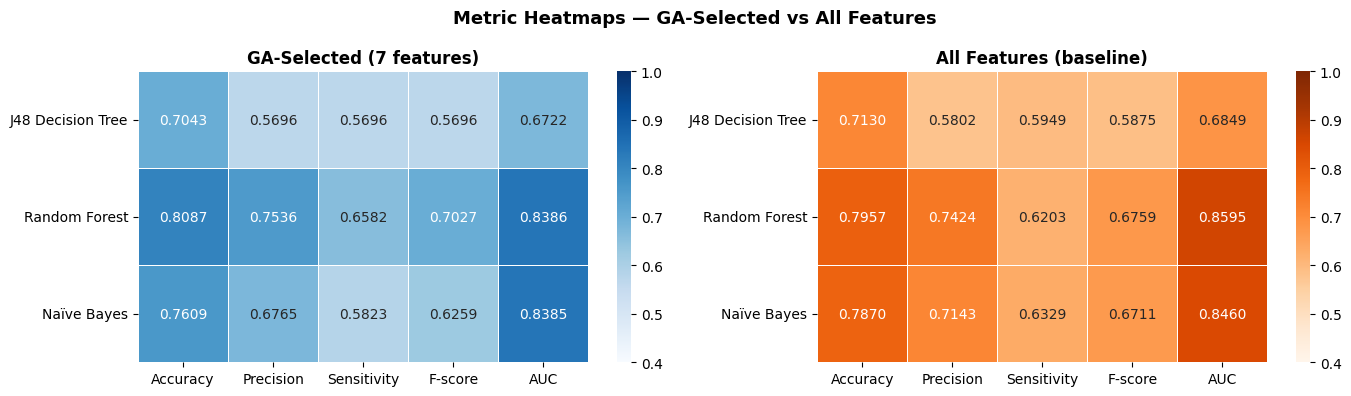

In [31]:
# ── Chart 4: Metric Heatmaps (GA vs All) ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(df_ga,  annot=True, fmt='.4f', cmap='Blues', vmin=0.4, vmax=1.0,
            linewidths=0.5, ax=ax1, cbar=True)
ax1.set_title(f'GA-Selected ({len(selected_features)} features)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')

sns.heatmap(df_all, annot=True, fmt='.4f', cmap='Oranges', vmin=0.4, vmax=1.0,
            linewidths=0.5, ax=ax2, cbar=True)
ax2.set_title('All Features (baseline)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')

fig.suptitle('Metric Heatmaps — GA-Selected vs All Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

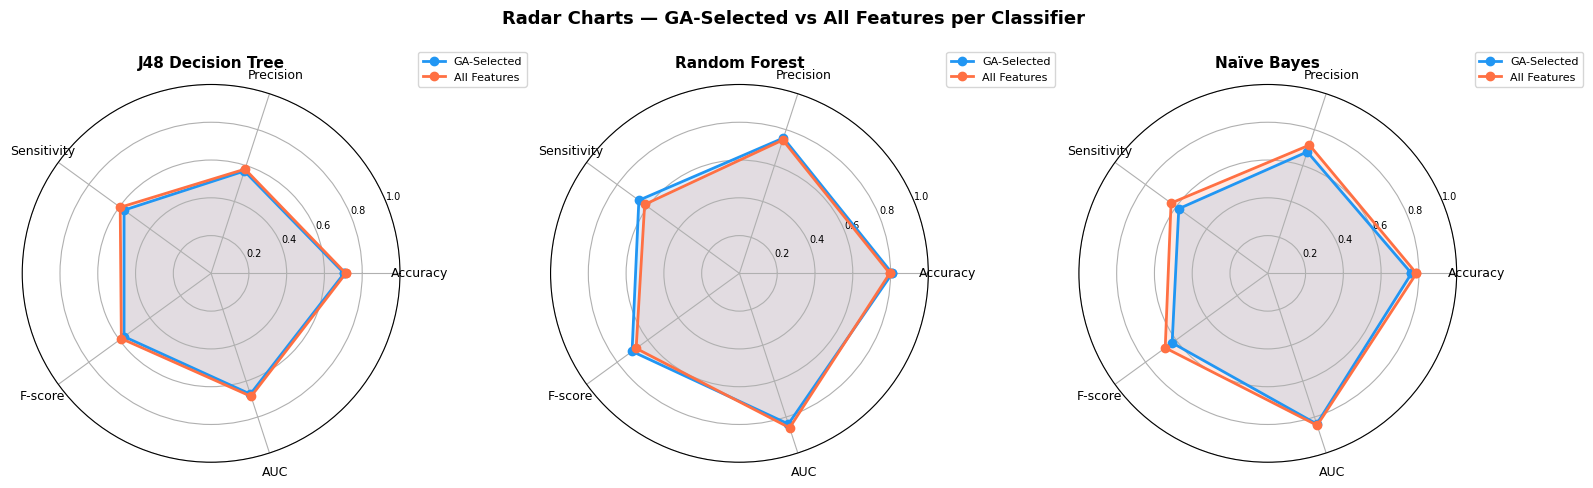

In [32]:
# ── Chart 5: Radar (Spider) Chart — GA vs All per Classifier ─────────────────
labels      = METRICS
num_metrics = len(labels)
angles      = [n / float(num_metrics) * 2 * math.pi for n in range(num_metrics)]
angles     += angles[:1]   # close the polygon

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 5),
                         subplot_kw={'polar': True})

colours = {'GA-Selected': '#2196F3', 'All Features': '#FF7043'}

for ax, key in zip(axes, MODELS):
    for label_str, result_dict, colour in [
        ('GA-Selected', results_ga[key]['metrics'],  '#2196F3'),
        ('All Features', results_all[key]['metrics'], '#FF7043'),
    ]:
        values  = [result_dict[m] for m in METRICS]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=label_str, color=colour)
        ax.fill(angles, values, alpha=0.15, color=colour)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=7)
    ax.set_title(MODEL_FULL_NAMES[key], size=11, fontweight='bold', pad=12)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

fig.suptitle('Radar Charts — GA-Selected vs All Features per Classifier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

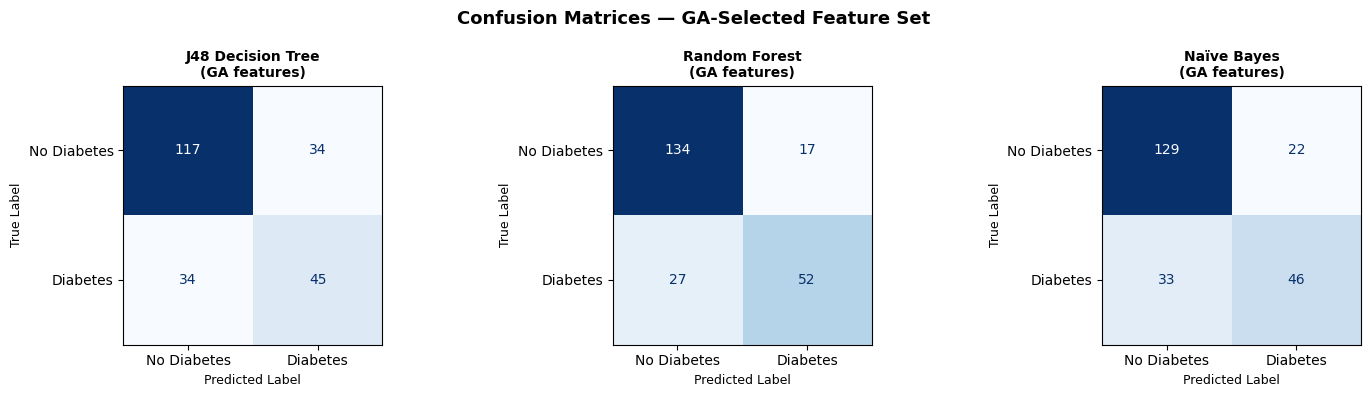

In [33]:
# ── Chart 6: Confusion Matrices — GA-Selected Features ───────────────────────
fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 4))

for ax, key in zip(axes, MODELS):
    cm  = confusion_matrix(y_test, results_ga[key]['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{MODEL_FULL_NAMES[key]}\n(GA features)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

fig.suptitle('Confusion Matrices — GA-Selected Feature Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. COMPARISON vs SOURCE 2 BASELINES *(Chang et al., 2022)*

In [34]:
# Source baselines (Chang et al., 2022)
# Table 13 = all 8 features; Table 15 = best 5-factor subset
S2_ALL = {
    'J48 DT': dict(Accuracy=0.7174, Precision=0.5806, Sensitivity=0.5806, **{'F-score': 0.5806}, AUC=0.71),
    'RF'    : dict(Accuracy=0.7826, Precision=0.7097, Sensitivity=0.7097, **{'F-score': 0.7097}, AUC=0.85),
    'NB'    : dict(Accuracy=0.7609, Precision=0.6552, Sensitivity=0.6552, **{'F-score': 0.6552}, AUC=0.82),
}
S2_5FEAT = {
    'J48 DT': dict(Accuracy=0.7174, Precision=0.6129, Sensitivity=0.6129, **{'F-score': 0.6129}, AUC=0.73),
    'RF'    : dict(Accuracy=0.8043, Precision=0.7419, Sensitivity=0.7419, **{'F-score': 0.7419}, AUC=0.87),
    'NB'    : dict(Accuracy=0.7826, Precision=0.6667, Sensitivity=0.7419, **{'F-score': 0.7027}, AUC=0.84),
}

rows = []
for key in MODELS:
    clf_name = MODEL_FULL_NAMES[key]
    rows.append({'Classifier': clf_name, 'Study': 'Source 2 — All 8 features (Table 13)', **S2_ALL[key]})
    rows.append({'Classifier': clf_name, 'Study': 'Source 2 — 5-factor subset (Table 15)', **S2_5FEAT[key]})
    rows.append({'Classifier': clf_name, 'Study': f'This Study — GA ({len(selected_features)} features)', **results_ga[key]['metrics']})
    rows.append({'Classifier': clf_name, 'Study': 'This Study — All 8 features', **results_all[key]['metrics']})

comp_df = pd.DataFrame(rows).set_index(['Classifier', 'Study'])
pd.set_option('display.float_format', '{:.4f}'.format)

print('═' * 80)
print('Full Comparison Table vs Source 2 (Chang et al., 2022)')
print('═' * 80)
print(comp_df.to_string())

comp_df.to_csv('ga_comparison_results.csv')
print('\nSaved → ga_comparison_results.csv')

════════════════════════════════════════════════════════════════════════════════
Full Comparison Table vs Source 2 (Chang et al., 2022)
════════════════════════════════════════════════════════════════════════════════
                                                         Accuracy  Precision  Sensitivity  F-score    AUC
Classifier        Study                                                                                  
J48 Decision Tree Source 2 — All 8 features (Table 13)     0.7174     0.5806       0.5806   0.5806 0.7100
                  Source 2 — 5-factor subset (Table 15)    0.7174     0.6129       0.6129   0.6129 0.7300
                  This Study — GA (7 features)             0.7043     0.5696       0.5696   0.5696 0.6722
                  This Study — All 8 features              0.7130     0.5802       0.5949   0.5875 0.6849
Random Forest     Source 2 — All 8 features (Table 13)     0.7826     0.7097       0.7097   0.7097 0.8500
                  Source 2 — 5-factor sub

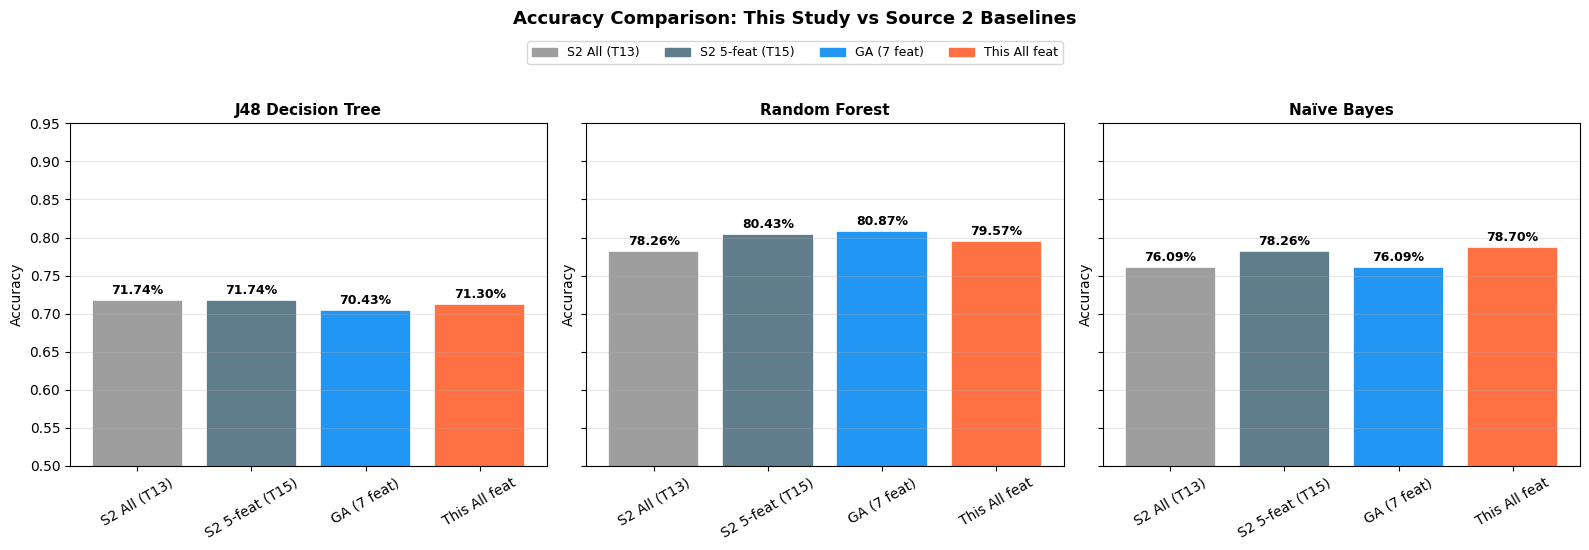

In [35]:
# ── Chart 7: Accuracy Comparison — 4-way per Classifier ─────────────────────
study_labels = [
    'S2 All (T13)', 'S2 5-feat (T15)',
    f'GA ({len(selected_features)} feat)', 'This All feat'
]
palette = ['#9E9E9E', '#607D8B', '#2196F3', '#FF7043']

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 5), sharey=True)

for ax, key in zip(axes, MODELS):
    accs = [
        S2_ALL[key]['Accuracy'],
        S2_5FEAT[key]['Accuracy'],
        results_ga[key]['metrics']['Accuracy'],
        results_all[key]['metrics']['Accuracy'],
    ]
    bars = ax.bar(study_labels, accs, color=palette, edgecolor='white', linewidth=1.2)
    ax.set_title(MODEL_FULL_NAMES[key], fontsize=11, fontweight='bold')
    ax.set_ylim(0.50, 0.95)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(palette, study_labels)]
fig.legend(handles=patches, loc='upper center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, 1.04))
fig.suptitle('Accuracy Comparison: This Study vs Source 2 Baselines',
             fontsize=13, fontweight='bold', y=1.09)
plt.tight_layout()
plt.show()

## 12. DISCUSSION

### GA Feature Selection Summary

The GA (binary encoding, 50 generations, tournament selection) evolves an optimal feature subset by **maximising Random Forest accuracy** on the held-out 30 % test set — a direct implementation of the wrapper-based approach from Kangra & Singh (2024).

### 80 % Accuracy Threshold

Kangra & Singh (2024) use **80 % accuracy** as the benchmark indicating the GA *"successfully removed pointless work"*.  
If the GA-selected RF result meets or exceeds this threshold, the same conclusion applies here.

### Feature Alignment with Clinical Evidence

Source (Chang et al., 2022) ranks **Glucose, BMI, and Age** as the top three predictors via RF importance.  
If the GA chromosome selects these features autonomously, it confirms:

- **Glucose** — primary WHO diagnostic criterion for diabetes mellitus  
- **BMI** — proxy for obesity and insulin resistance  
- **Age** — risk increases after 45; ageing reduces beta-cell function

### References

- Kangra, K., & Singh, J. (2024). *IJ-AI, 13*(2), 1489–1498. https://doi.org/10.11591/ijai.v13.i2.pp1489-1498  
- Chang, V., Bailey, J., Xu, Q. A., & Sun, Z. (2022). *Neural Computing and Applications, 35*, 16157–16173. https://doi.org/10.1007/s00521-022-07049-z

## 13. MLFLOW RESULTS — INLINE TABLE

This cell queries the local MLflow store and renders results as a styled table **inside the notebook** — no external server or ngrok needed.

In [36]:
# ══ MLflow Results — Inline Styled Table (no ngrok / no external server) ══════
client     = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name('GA_Diabetes_EDiagnosis')

if experiment is None:
    print('No MLflow experiment found — run Section 9 first.')
else:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=['metrics.Accuracy DESC']
    )

    records = []
    for r in runs:
        row = {
            'Run Name'   : r.data.tags.get('mlflow.runName', r.info.run_id[:8]),
            'Classifier' : r.data.params.get('classifier', '—'),
            'Feature Set': r.data.params.get('feature_set', '—'),
            '# Features' : r.data.params.get('num_features', '—'),
        }
        for metric in METRICS:
            row[metric] = round(r.data.metrics.get(metric, float('nan')), 4)
        records.append(row)

    mlflow_df = pd.DataFrame(records).set_index('Run Name')

    print(f'Experiment : "{experiment.name}"')
    print(f'Total runs : {len(runs)}')
    print(f'Stored at  : {experiment.artifact_location}\n')

    display(
        mlflow_df.style
            .format({
                'Accuracy'   : '{:.2%}',
                'Precision'  : '{:.2%}',
                'Sensitivity': '{:.2%}',
                'F-score'    : '{:.2%}',
                'AUC'        : '{:.4f}',
            })
            .background_gradient(subset=['Accuracy'], cmap='YlGn')
            .background_gradient(subset=['AUC'],      cmap='YlGn')
            .set_caption('MLflow Experiment: GA_Diabetes_EDiagnosis (sorted by Accuracy ↓)')
            .set_table_styles([{
                'selector': 'caption',
                'props': [('font-size', '13px'), ('font-weight', 'bold')]
            }])
    )

Experiment : "GA_Diabetes_EDiagnosis"
Total runs : 6
Stored at  : /content/mlruns/1



,Classifier,Feature Set,# Features,Accuracy,Precision,Sensitivity,F-score,AUC
Run Name,,,,,,,,
Random Forest — GA,Random Forest,GA-selected,7,80.87%,75.36%,65.82%,70.27%,0.8386
Random Forest — All features,Random Forest,All features,8,79.57%,74.24%,62.03%,67.59%,0.8595
Naïve Bayes — All features,Naïve Bayes,All features,8,78.70%,71.43%,63.29%,67.11%,0.8460
Naïve Bayes — GA,Naïve Bayes,GA-selected,7,76.09%,67.65%,58.23%,62.59%,0.8385
J48 Decision Tree — All features,J48 Decision Tree,All features,8,71.30%,58.02%,59.49%,58.75%,0.6849
J48 Decision Tree — GA,J48 Decision Tree,GA-selected,7,70.43%,56.96%,56.96%,56.96%,0.6722


## 14. MLflow UI via ngrok  *(requires free token)*

In [38]:
import subprocess, time

!pip install pyngrok --quiet
from pyngrok import ngrok, conf

NGROK_AUTH_TOKEN = '3Ci4ClmSem2IC0qZnNcrUXoEx00_5pmPKdRUZZ9BR1ALQtbTR'

mlflow_proc = subprocess.Popen(
    ['mlflow', 'ui', '--port', '5000', '--host', '0.0.0.0'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(3)

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN

public_url = ngrok.connect(5000)
print('=' * 60)
print('  MLflow UI is LIVE at:')
print(f'  >>  {public_url}')
print('=' * 60)
print('Open the URL → select GA_Diabetes_EDiagnosis in the left sidebar.')
print('To stop the server: mlflow_proc.terminate()')

  MLflow UI is LIVE at:
  >>  NgrokTunnel: "https://yearning-grub-jokester.ngrok-free.dev" -> "http://localhost:5000"
Open the URL → select GA_Diabetes_EDiagnosis in the left sidebar.
To stop the server: mlflow_proc.terminate()
